In [212]:
import os
import numpy as np
import SimpleITK as sitk
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from matplotlib.ticker import MultipleLocator

# ==========================================================
# Helper
# ==========================================================
def load_nii(path):
    img = sitk.ReadImage(path)
    return sitk.GetArrayFromImage(img)


# ==========================================================
# VOI STATISTICS WITH RELATIVE DIFFERENCES
# ==========================================================
def statistics_multiple_vois(dose_map, voi_folder, output_txt, method_name="Method"):

    voi_files = sorted([
        f for f in os.listdir(voi_folder)
        if f.endswith(".nii") or f.endswith(".nii.gz")
    ])

    results = []

    with open(output_txt, "w") as f:

        for voi_name in voi_files:

            voi_path = os.path.join(voi_folder, voi_name)
            voi_mask = load_nii(voi_path) > 0

            if np.count_nonzero(voi_mask) == 0:
                continue

            values = dose_map[voi_mask]

            mean_dose = np.mean(values)
            std_dose  = np.std(values)
            min_dose  = np.min(values)
            max_dose  = np.max(values)

            f.write(f"VOI: {voi_name}\n")
            f.write(f"  Voxels: {len(values)}\n")
            f.write(f"  Mean Absorbed Dose: {mean_dose:.4f}\n")  
            f.write(f"  Std: {std_dose:.4f}\n")                  
            f.write(f"  Min: {min_dose:.4f}\n")                
            f.write(f"  Max: {max_dose:.4f}\n\n")                

            results.append({
                "VOI": voi_name,
                "Voxels": len(values),
                "Mean Absorbed Dose": mean_dose,  # Store as float for calculations
                "Std": std_dose,                    # Store as float for calculations
                "Min": min_dose,
                "Max": max_dose
            })

    df = pd.DataFrame(results)
    
    # Format the output for display
    df_display = df.copy()
    df_display["Mean Absorbed Dose"] = df_display["Mean Absorbed Dose"].map("{:.4f}".format)
    df_display["Std"] = df_display["Std"].map("{:.4f}".format)
    df_display["Min"] = df_display["Min"].map("{:.4f}".format)
    df_display["Max"] = df_display["Max"].map("{:.4f}".format)

    print(f"\nStatistics saved to {output_txt}\n")
    print(f"Results for {method_name}:")
    display(df_display)

    return df


# ==========================================================
# COMPARE METHODS AND CALCULATE RELATIVE DIFFERENCES
# ==========================================================
def compare_methods(df_digital, df_hu, df_vsv, output_txt="method_comparison.txt"):
    """
    Compare mean absorbed doses between different methods and calculate relative differences.
    
    Parameters:
    df_digital: DataFrame with Digital Phantom statistics
    df_hu: DataFrame with HU Phantom statistics
    df_vsv: DataFrame with VSV statistics
    output_txt: File to save comparison results
    """
    
    # Set index to VOI for alignment
    digital = df_digital.set_index("VOI")
    hu = df_hu.set_index("VOI")
    vsv = df_vsv.set_index("VOI")
    
    # Get common VOIs across all three methods
    common_vois = sorted(set(digital.index) & set(hu.index) & set(vsv.index))
    
    # Define desired order for main VOIs
    desired_order = [
        'nlv.nii', 
        'ptv.nii', 
        'ptv_no_necrotic.nii', 
        'WLV.nii', 
        'RWLV.nii', 
        'necrotic.nii'
    ]
    
    # Add tumour files in order
    tumour_files = sorted([f for f in common_vois if 'tumour' in f.lower() or 'tumor' in f.lower()])
    def extract_tumor_number(filename):
        numbers = ''.join(filter(str.isdigit, filename))
        return int(numbers) if numbers else 0
    tumour_files.sort(key=extract_tumor_number)
    
    # Combine in desired order
    ordered_vois = []
    for voi in desired_order:
        if voi in common_vois:
            ordered_vois.append(voi)
    ordered_vois.extend(tumour_files)
    
    # Create nicer display labels
    display_labels = []
    for voi in ordered_vois:
        if voi == 'nlv.nii':
            display_labels.append('NLV')
        elif voi == 'ptv.nii':
            display_labels.append('PTV')
        elif voi == 'ptv_no_necrotic.nii':
            display_labels.append('PTV (No Necrotic)')
        elif voi == 'WLV.nii':
            display_labels.append('WLV')
        elif voi == 'RWLV.nii':
            display_labels.append('RWLV')
        elif voi == 'necrotic.nii':
            display_labels.append('Necrotic')
        elif 'tumour' in voi.lower() or 'tumor' in voi.lower():
            tumor_num = ''.join(filter(str.isdigit, voi))
            display_labels.append(f'Tumour {tumor_num}' if tumor_num else voi.replace('.nii', ''))
        else:
            display_labels.append(voi.replace('.nii', ''))
    
    # Extract mean dose values
    digital_vals = digital.loc[ordered_vois, "Mean Absorbed Dose"].values
    hu_vals = hu.loc[ordered_vois, "Mean Absorbed Dose"].values
    vsv_vals = vsv.loc[ordered_vois, "Mean Absorbed Dose"].values
    
    # Calculate relative differences (%)
    # Relative difference = (method1 - method2) / method2 * 100
    rel_diff_digital_vsv = (digital_vals - vsv_vals) / vsv_vals * 100
    rel_diff_hu_vsv = (hu_vals - vsv_vals) / vsv_vals * 100
    rel_diff_digital_hu = (hu_vals- digital_vals) / ((digital_vals + hu_vals)/2) * 100

    
    # Volume-weighted symmetric difference (HU vs Digital)
    voxel_counts = digital.loc[ordered_vois, "Voxels"].values

    overall_weighted_diff = np.sum(voxel_counts * rel_diff_digital_hu) / np.sum(voxel_counts)
    
    # Create comparison DataFrame
    comparison_data = []
    for i, voi in enumerate(ordered_vois):
        comparison_data.append({
            "VOI": display_labels[i],
            "Digital (Gy)": f"{digital_vals[i]:.4f}",
            "HU (Gy)": f"{hu_vals[i]:.4f}",
            "VSV (Gy)": f"{vsv_vals[i]:.4f}",
            "Digital vs VSV (%)": f"{rel_diff_digital_vsv[i]:.2f}",
            "HU vs VSV (%)": f"{rel_diff_hu_vsv[i]:.2f}",
            "Digital vs HU (%)": f"{rel_diff_digital_hu[i]:.2f}"
        })
    
    comparison_df = pd.DataFrame(comparison_data)
    
    # Save to text file
    with open(output_txt, "w") as f:
        f.write("="*100 + "\n")
        f.write("COMPARISON OF MEAN ABSORBED DOSES BETWEEN METHODS\n")
        f.write("="*100 + "\n\n")
        
        f.write("Absolute Values (Gy):\n")
        f.write("-"*50 + "\n")
        for i, voi in enumerate(ordered_vois):
            f.write(f"{display_labels[i]:<20}: Digital={digital_vals[i]:.4f}, HU={hu_vals[i]:.4f}, VSV={vsv_vals[i]:.4f}\n")
        
        f.write("\nRelative Differences (%):\n")
        f.write("-"*50 + "\n")
        f.write("(Positive means method has higher dose than reference)\n\n")
        
        f.write("Digital Phantom vs VSV:\n")
        for i, voi in enumerate(ordered_vois):
            f.write(f"{display_labels[i]:<20}: {rel_diff_digital_vsv[i]:+.2f}%\n")
        
        f.write("\nHU Phantom vs VSV:\n")
        for i, voi in enumerate(ordered_vois):
            f.write(f"{display_labels[i]:<20}: {rel_diff_hu_vsv[i]:+.2f}%\n")
        
        f.write("\nDigital Phantom vs HU Phantom:\n")
        for i, voi in enumerate(ordered_vois):
            f.write(f"{display_labels[i]:<20}: {rel_diff_digital_hu[i]:+.2f}%\n")
        
        # Calculate summary statistics
        f.write("\n" + "="*100 + "\n")
        f.write("SUMMARY STATISTICS\n")
        f.write("="*100 + "\n")
        
        f.write("\nDigital vs VSV relative differences (%):\n")
        f.write(f"  Mean: {np.mean(rel_diff_digital_vsv):+.2f}%\n")
        f.write(f"  Std:  {np.std(rel_diff_digital_vsv):.2f}%\n")
        f.write(f"  Min:  {np.min(rel_diff_digital_vsv):+.2f}%\n")
        f.write(f"  Max:  {np.max(rel_diff_digital_vsv):+.2f}%\n")
        f.write(f"  |Diff| < 5%: {np.sum(np.abs(rel_diff_digital_vsv) < 5)}/{len(rel_diff_digital_vsv)} VOIs\n")
        
        f.write("\nHU vs VSV relative differences (%):\n")
        f.write(f"  Mean: {np.mean(rel_diff_hu_vsv):+.2f}%\n")
        f.write(f"  Std:  {np.std(rel_diff_hu_vsv):.2f}%\n")
        f.write(f"  Min:  {np.min(rel_diff_hu_vsv):+.2f}%\n")
        f.write(f"  Max:  {np.max(rel_diff_hu_vsv):+.2f}%\n")
        f.write(f"  |Diff| < 5%: {np.sum(np.abs(rel_diff_hu_vsv) < 5)}/{len(rel_diff_hu_vsv)} VOIs\n")
        
        f.write("\nDigital vs HU relative differences (%):\n")
        f.write(f"  Mean: {np.mean(rel_diff_digital_hu):+.2f}%\n")
        f.write(f"  Std:  {np.std(rel_diff_digital_hu):.2f}%\n")
        f.write(f"  Min:  {np.min(rel_diff_digital_hu):+.2f}%\n")
        f.write(f"  Max:  {np.max(rel_diff_digital_hu):+.2f}%\n")
        f.write(f"  |Diff| < 5%: {np.sum(np.abs(rel_diff_digital_hu) < 5)}/{len(rel_diff_digital_hu)} VOIs\n")

        f.write("\nVolume-Weighted Overall Difference (HU vs Digital):\n")
        f.write(f"  {overall_weighted_diff:+.2f}%\n")

    
    print(f"\nComparison saved to {output_txt}\n")
    print("Relative Differences Between Methods:")
    display(comparison_df)
    
    return comparison_df, rel_diff_digital_vsv, rel_diff_hu_vsv, rel_diff_digital_hu, ordered_vois, display_labels, overall_weighted_diff


# ==========================================================
# Plot style
# ==========================================================
def setup_latex():
    plt.rcParams.update({
        "text.usetex": False,
        "font.family": "STIXGeneral",
        "mathtext.fontset": "stix",
        "font.size": 28,
        "axes.labelsize": 28,
        "legend.fontsize": 23,
        "xtick.labelsize": 28,
        "ytick.labelsize": 28,
        "axes.linewidth": 1.5,
        "lines.linewidth": 3,
    })

# ==========================================================
# DVH FOR MAIN VOIs
# ==========================================================
def combined_dvh_main_vois(ax, vsv_dose_path, mc_dose_path, voi_folder):

    vsv = load_nii(vsv_dose_path)
    mc  = load_nii(mc_dose_path)

    voi_list = [
        'nlv.nii',
        'ptv.nii',
        'ptv_no_necrotic.nii',
        'WLV.nii',
        'RWLV.nii',
        'necrotic.nii'
    ]

    voi_labels = {
        "nlv.nii": "NLV",
        "ptv.nii": "PTV",
        "ptv_no_necrotic.nii": "PTV (No Necrotic)",
        "WLV.nii": "WLV",
        "RWLV.nii": "RWLV",
        "necrotic.nii": "Necrotic"
    }

    existing_vois = [
        v for v in voi_list if os.path.exists(os.path.join(voi_folder, v))
    ]

    colors = [
        (31/255,119/255,180/255),
        (255/255,160/255,70/255), 
        (44/255,160/255,44/255),
        (214/255,39/255,40/255),
        (148/255,103/255,189/255),
        (140/255,86/255,75/255),
    ]

    global_max_dose = 0
    dose_data = []

    for voi_name in existing_vois:
        voi_mask = load_nii(os.path.join(voi_folder, voi_name)) > 0
        dose_vsv = vsv[voi_mask]
        dose_mc  = mc[voi_mask]

        if len(dose_vsv)>0: global_max_dose=max(global_max_dose,dose_vsv.max())
        if len(dose_mc)>0:  global_max_dose=max(global_max_dose,dose_mc.max())

        dose_data.append((voi_name,dose_vsv,dose_mc))

    x_limit=max(610,global_max_dose*1.05)
    bins=np.linspace(0,x_limit,200)

    for idx,(voi_name,dose_vsv,dose_mc) in enumerate(dose_data):

        color=colors[idx%len(colors)]
        if len(dose_vsv)==0 or len(dose_mc)==0:
            continue

        hist_vsv,edges=np.histogram(dose_vsv,bins=bins)
        cum_vsv=np.cumsum(hist_vsv[::-1])[::-1]
        rel_vsv=100.0*cum_vsv/cum_vsv[0]

        hist_mc,_=np.histogram(dose_mc,bins=bins)
        cum_mc=np.cumsum(hist_mc[::-1])[::-1]
        rel_mc=100.0*cum_mc/cum_mc[0]

        display_name=voi_labels.get(voi_name,voi_name)

        ax.plot(edges[:-1],rel_mc,color=color,linewidth=2,
                label=f"{display_name} (MC)")
        ax.plot(edges[:-1],rel_vsv,'--',color=color,linewidth=1.5,
                label=f"{display_name} (VSV)",alpha=0.8)

    ax.set_xlabel("Absorbed Dose (Gy)",labelpad=16)
    ax.set_ylabel(r"Volume ($\%$)")

    ax.set_ylim(0,105)
    ax.set_xlim(0,x_limit)

    ax.xaxis.set_major_locator(MultipleLocator(100))
    ax.yaxis.set_major_locator(MultipleLocator(20))
    ax.grid(True,alpha=0.3)

    ax.legend(frameon=True,edgecolor='black',fontsize=15,loc='upper right')


# ==========================================================
# DVH FOR TUMORS
# ==========================================================
def combined_dvh_tumors(ax, vsv_dose_path, mc_dose_path, voi_folder):

    vsv=load_nii(vsv_dose_path)
    mc=load_nii(mc_dose_path)

    tumor_files=[f for f in os.listdir(voi_folder)
        if (f.endswith(".nii") or f.endswith(".nii.gz"))
        and ("tumour" in f.lower() or "tumor" in f.lower())]

    def extract_tumor_number(filename):
        numbers=''.join(filter(str.isdigit,filename))
        return int(numbers) if numbers else 0

    tumor_files.sort(key=extract_tumor_number)

    from matplotlib.cm import tab20
    colors=[tab20(i) for i in range(len(tumor_files))]

    global_max_dose=0
    dose_data=[]

    for voi_name in tumor_files:
        voi_mask=load_nii(os.path.join(voi_folder,voi_name))>0
        dose_vsv=vsv[voi_mask]
        dose_mc=mc[voi_mask]

        if len(dose_vsv)>0: global_max_dose=max(global_max_dose,dose_vsv.max())
        if len(dose_mc)>0:  global_max_dose=max(global_max_dose,dose_mc.max())

        dose_data.append((voi_name,dose_vsv,dose_mc))

    x_limit=max(620,global_max_dose*1.05)
    bins=np.linspace(0,x_limit,200)

    for idx,(voi_name,dose_vsv,dose_mc) in enumerate(dose_data):

        color=colors[idx%len(colors)]
        if len(dose_vsv)==0 or len(dose_mc)==0:
            continue

        hist_vsv,edges=np.histogram(dose_vsv,bins=bins)
        cum_vsv=np.cumsum(hist_vsv[::-1])[::-1]
        rel_vsv=100.0*cum_vsv/cum_vsv[0]

        hist_mc,_=np.histogram(dose_mc,bins=bins)
        cum_mc=np.cumsum(hist_mc[::-1])[::-1]
        rel_mc=100.0*cum_mc/cum_mc[0]

        tumor_num=''.join(filter(str.isdigit,voi_name))
        display_name=f"Tumour {tumor_num}" if tumor_num else voi_name

        ax.plot(edges[:-1],rel_mc,color=color,linewidth=2,
                label=f"{display_name} (MC)")
        ax.plot(edges[:-1],rel_vsv,'--',color=color,linewidth=1.5,
                label=f"{display_name} (VSV)",alpha=0.8)

    ax.set_xlabel("Absorbed Dose (Gy)",labelpad=16)

    ax.set_ylim(0,105)
    ax.set_xlim(0,x_limit)

    ax.xaxis.set_major_locator(MultipleLocator(100))
    ax.yaxis.set_major_locator(MultipleLocator(20))
    ax.grid(True,alpha=0.3)

    ax.legend(frameon=True,edgecolor='black',fontsize=11.6,loc='upper right')

# ==========================================================
# DOSE BAR PLOT WITH STANDARD DEVIATION ERROR BARS
# ==========================================================
def dose_barplot_latex(df_hu, df_digital, df_vsv, use_intersection=True):
    """
    Create a bar plot comparing mean absorbed doses from three different methods
    with error bars representing the standard deviation.
    
    Parameters:
    df_hu: DataFrame with HU Phantom statistics (includes Std column)
    df_digital: DataFrame with Digital Phantom statistics (includes Std column)
    df_vsv: DataFrame with VSV statistics (includes Std column)
    use_intersection: If True, use only VOIs present in all three DataFrames
    """
    setup_latex()

    # Define the color palette inside the function
    # RGB tuples (0–255)
    palette_rgb = [
        (20, 144, 228),   # blue
        (0, 94, 94),      # teal
        (159, 25, 85),    # dark magenta
        (252, 79, 88),    # pink-red
        (250, 78, 86)     # red
    ]

    # Index by VOI for alignment
    hu = df_hu.set_index("VOI")
    dg = df_digital.set_index("VOI")
    vs = df_vsv.set_index("VOI")

    if use_intersection:
        common = sorted(set(hu.index) & set(dg.index) & set(vs.index))
    else:
        # union (will produce NaNs if missing)
        common = sorted(set(hu.index) | set(dg.index) | set(vs.index))
    
    # Define the desired order of VOIs
    desired_order = [
        'nlv.nii', 
        'ptv.nii', 
        'ptv_no_necrotic.nii', 
        'WLV.nii', 
        'RWLV.nii', 
        'necrotic.nii'
    ]
    
    # Add tumour files in order
    tumour_files = sorted([f for f in common if 'tumour' in f.lower() or 'tumor' in f.lower()])
    # Sort tumour files by number
    def extract_tumor_number(filename):
        numbers = ''.join(filter(str.isdigit, filename))
        return int(numbers) if numbers else 0
    tumour_files.sort(key=extract_tumor_number)
    
    # Combine in desired order: main VOIs first, then tumours
    ordered_vois = []
    for voi in desired_order:
        if voi in common:
            ordered_vois.append(voi)
    
    # Add all tumour files
    ordered_vois.extend(tumour_files)
    
    # Use the ordered list instead of 'common'
    common = ordered_vois

    # Convert string values back to float for plotting
    hu_vals = pd.to_numeric(hu.loc[common, "Mean Absorbed Dose"]).to_numpy()
    dg_vals = pd.to_numeric(dg.loc[common, "Mean Absorbed Dose"]).to_numpy()
    vs_vals = pd.to_numeric(vs.loc[common, "Mean Absorbed Dose"]).to_numpy()
    
    # Get standard deviation values for error bars
    hu_std = pd.to_numeric(hu.loc[common, "Std"]).to_numpy()
    dg_std = pd.to_numeric(dg.loc[common, "Std"]).to_numpy()
    vs_std = pd.to_numeric(vs.loc[common, "Std"]).to_numpy()

    # Create nicer labels for display
    display_labels = []
    for voi in common:
        if voi == 'nlv.nii':
            display_labels.append('NLV')
        elif voi == 'ptv.nii':
            display_labels.append('PTV')
        elif voi == 'ptv_no_necrotic.nii':
            display_labels.append('PTV (No Necrotic)')
        elif voi == 'WLV.nii':
            display_labels.append('WLV')
        elif voi == 'RWLV.nii':
            display_labels.append('RWLV')
        elif voi == 'necrotic.nii':
            display_labels.append('Necrotic')
        elif 'tumour' in voi.lower() or 'tumor' in voi.lower():
            tumor_num = ''.join(filter(str.isdigit, voi))
            display_labels.append(f'Tumour {tumor_num}' if tumor_num else voi.replace('.nii', ''))
        else:
            display_labels.append(voi.replace('.nii', ''))

    # SPACING BETWEEN VOI GROUPS
    spacing_factor = 1.8
    x = np.arange(len(common)) * spacing_factor
    
    # Adjust bar width to maintain proportions with increased spacing
    width = 0.4  # Slightly wider bars to compensate for increased spacing

    # Fig size - slightly wider to accommodate increased spacing
    fig, ax = plt.subplots(figsize=(28, 13))  # Increased from 26 to 28

    # Convert RGB tuples (0-255) to matplotlib format (0-1)
    palette = [(r/255, g/255, b/255) for r, g, b in palette_rgb]
    
    # Assign colors from your palette in the desired order
    c_digital = palette[2]  # dark magenta for Digital Phantom
    c_hu = palette[0]        # blue for HU Phantom
    c_vsv = palette[1]       # teal for VSV

    # Set grid to be behind by using low zorder
    ax.grid(True, alpha=0.3, zorder=0)
    
    # Digital Phantom (left), HU Phantom (middle), VSV (right)
    # Set higher zorder so bars appear in front of grid
    bars1 = ax.bar(x - width, dg_vals, width, label="Digital Phantom", color=c_digital, zorder=3)
    bars2 = ax.bar(x, hu_vals, width, label="HU Phantom", color=c_hu, zorder=3)
    bars3 = ax.bar(x + width, vs_vals, width, label="VSV", color=c_vsv, zorder=3)
    
    # Error bars for all three methods using standard deviation
    # Scale the error bars if needed by multiplying the std values
    error_scale = 0.4 
    
    # Error bars for Digital Phantom
    ax.errorbar(x - width, dg_vals, yerr=dg_std * error_scale, fmt='o', 
                ecolor='black', capsize=4, capthick=2, marker='o', markersize=4, elinewidth=2, markerfacecolor='black', markeredgecolor='black', zorder=4)
    
    # Error bars for HU Phantom
    ax.errorbar(x, hu_vals, yerr=hu_std * error_scale, fmt='o', 
                ecolor='black', capsize=4, capthick=2, marker='o', markersize=4, elinewidth=2, markerfacecolor='black', markeredgecolor='black', zorder=4)
    
    # Error bars for VSV
    ax.errorbar(x + width, vs_vals, yerr=vs_std * error_scale, fmt='o', 
                ecolor='black', capsize=4, capthick=2, marker='o', markersize=4, elinewidth=2, markerfacecolor='black', markeredgecolor='black', zorder=4)


    ax.set_ylabel("Absorbed Dose (Gy)", labelpad=16, fontsize=33)
    ax.set_xlabel("VOI", labelpad=16, fontsize=33)

    ax.set_xticks(x)
    ax.set_xticklabels(display_labels, rotation=45, ha='right')

    # Increase tick label sizes
    ax.tick_params(axis='x', labelsize=33)
    ax.tick_params(axis='y', labelsize=33)

    # Add some padding on the sides
    ax.set_xlim(x[0] - width*2, x[-1] + width*2)

    ax.legend(frameon=True, edgecolor="black", loc="upper left", fontsize=33)

    plt.tight_layout()
    return fig, ax

Calculating statistics for VSV...

Statistics saved to VSV_stats.txt

Results for VSV:


,VOI,Voxels,Mean Absorbed Dose,Std,Min,Max
0,RWLV.nii,291448,49.8305,84.4567,0.0000,609.7505
1,Tumour1.nii,350,466.4029,55.7297,389.7897,609.7505
2,Tumour2.nii,932,449.3900,45.7719,389.5192,600.4971
3,Tumour3.nii,221,426.8202,22.3099,390.5407,487.1923
4,Tumour4.nii,469,427.7602,27.8734,389.6504,524.2223
5,Tumour5.nii,132,441.9292,39.5270,389.5275,539.3661
6,Tumour6.nii,42,434.6300,30.3914,392.3877,505.4650
7,Tumour7.nii,19,410.3127,12.5883,390.4970,435.6397
8,Tumour8.nii,107,420.7517,19.9718,389.6786,468.3548
9,WLV.nii,195696,68.1760,96.8555,0.0000,609.7505



Calculating statistics for HU Phantom...

Statistics saved to HU_stats.txt

Results for HU Phantom:


,VOI,Voxels,Mean Absorbed Dose,Std,Min,Max
0,RWLV.nii,291448,46.4914,84.9618,0.0000,601.2131
1,Tumour1.nii,350,463.6063,55.4310,379.4646,601.2131
2,Tumour2.nii,932,449.5394,45.6438,378.1844,601.1882
3,Tumour3.nii,221,431.3754,23.1960,388.4882,488.4215
4,Tumour4.nii,469,430.6385,28.0743,384.1275,526.3801
5,Tumour5.nii,132,438.4582,39.4375,379.8186,537.3268
6,Tumour6.nii,42,433.2643,31.3864,387.6643,514.0717
7,Tumour7.nii,19,408.3818,12.6038,385.3430,430.9962
8,Tumour8.nii,107,418.4901,19.9800,387.0642,469.6306
9,WLV.nii,195696,67.5312,96.7735,0.0000,601.2131



Calculating statistics for Digital Phantom...

Statistics saved to Digital_stats.txt

Results for Digital Phantom:


,VOI,Voxels,Mean Absorbed Dose,Std,Min,Max
0,RWLV.nii,291448,45.4882,83.3578,0.0000,596.2797
1,Tumour1.nii,350,457.9934,54.9148,376.7041,593.4213
2,Tumour2.nii,932,441.4500,45.1746,375.2870,596.2797
3,Tumour3.nii,221,419.2528,22.6279,377.8767,481.4636
4,Tumour4.nii,469,420.2256,28.4783,375.0379,521.1575
5,Tumour5.nii,132,435.6668,39.2803,376.9768,538.2068
6,Tumour6.nii,42,427.2266,30.5931,383.2325,506.4931
7,Tumour7.nii,19,402.6862,12.1533,376.2484,423.6971
8,Tumour8.nii,107,412.2461,19.8666,380.1184,462.2051
9,WLV.nii,195696,66.2408,94.8972,0.0000,596.2797



COMPARING METHODS - RELATIVE DIFFERENCES

Comparison saved to method_comparison.txt

Relative Differences Between Methods:


,VOI,Digital (Gy),HU (Gy),VSV (Gy),Digital vs VSV (%),HU vs VSV (%),Digital vs HU (%)
0,NLV,50.7676,51.7292,53.5409,-5.18,-3.38,1.88
1,PTV,93.4639,95.2520,95.9360,-2.58,-0.71,1.89
2,PTV (No Necrotic),111.8150,113.9121,114.7997,-2.60,-0.77,1.86
3,WLV,66.2408,67.5312,68.1760,-2.84,-0.95,1.93
4,RWLV,45.4882,46.4914,49.8305,-8.71,-6.70,2.18
5,Necrotic,30.3106,31.0348,31.0183,-2.28,0.05,2.36
6,Tumour 1,457.9934,463.6063,466.4029,-1.80,-0.60,1.22
7,Tumour 2,441.4500,449.5394,449.3900,-1.77,0.03,1.82
8,Tumour 3,419.2528,431.3754,426.8202,-1.77,1.07,2.85
9,Tumour 4,420.2256,430.6385,427.7602,-1.76,0.67,2.45



Volume-Weighted Overall Difference (HU vs Digital): +2.02%

CREATING BAR PLOT...


/tmp/ipykernel_11816/4198460176.py:547: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  ax.errorbar(x - width, dg_vals, yerr=dg_std * error_scale, fmt='o',
/tmp/ipykernel_11816/4198460176.py:551: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  ax.errorbar(x, hu_vals, yerr=hu_std * error_scale, fmt='o',
/tmp/ipykernel_11816/4198460176.py:555: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  ax.errorbar(x + width, vs_vals, yerr=vs_std * error_scale, fmt='o',


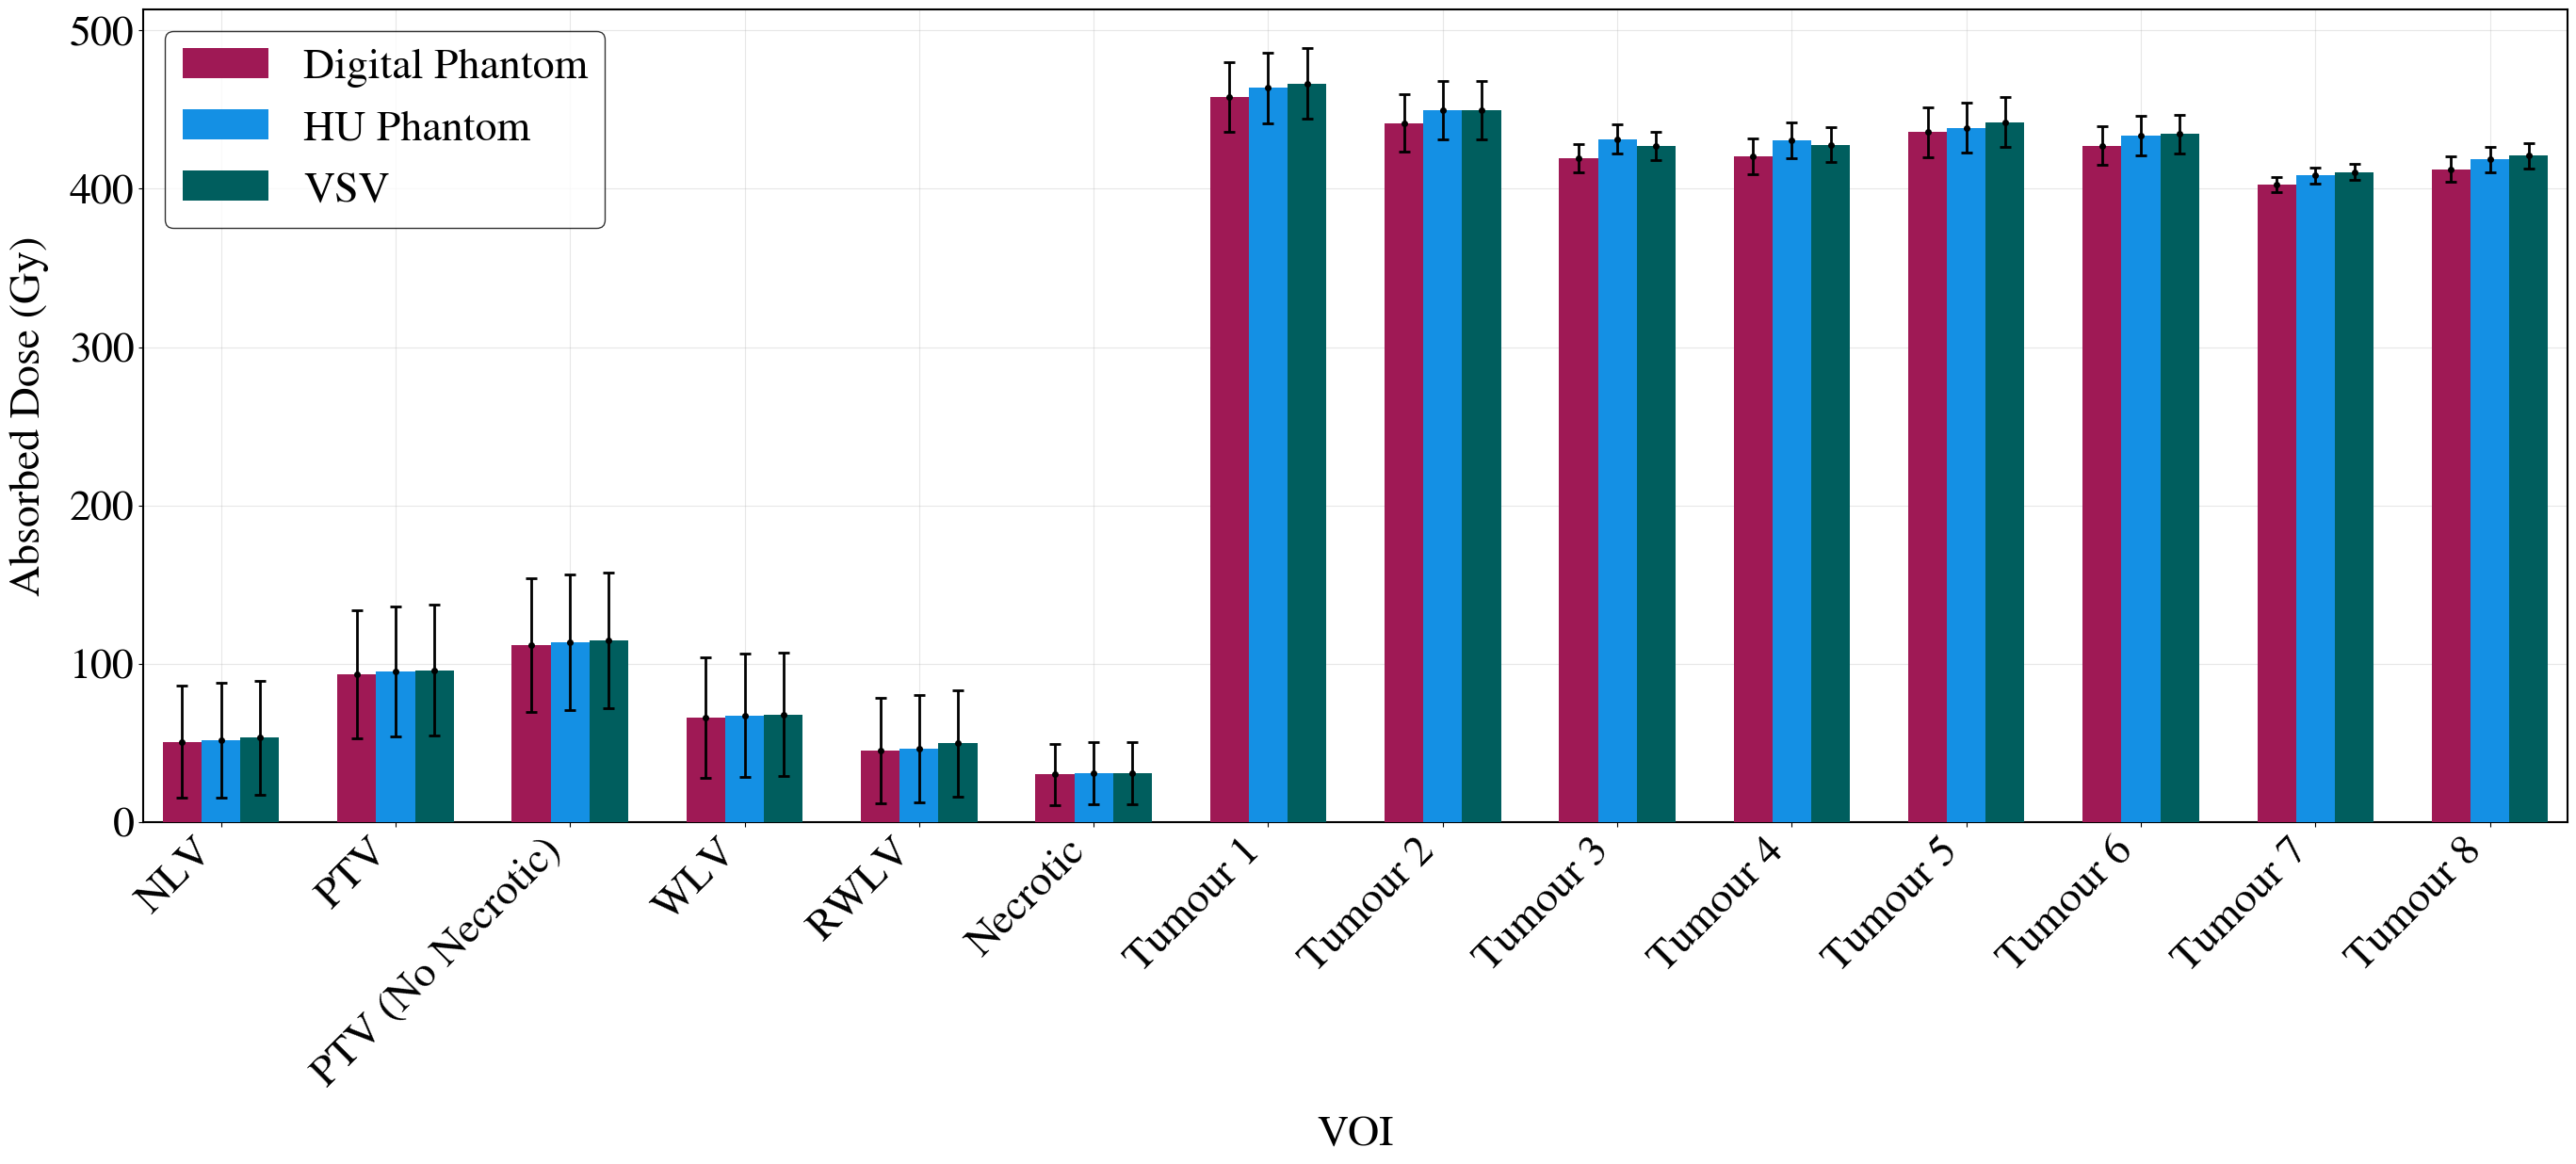


Analysis complete!


In [213]:
# ==========================================================
# MAIN
# ==========================================================
if __name__ == "__main__":

    setup_latex()

    vsv_dose_path = "/home/administrator/Champalimaud dados/Imagens/ab_dose_y90.nii"
    mc_dose_path_hu = "/home/administrator/Secretária/Results_MC_Dosimetry/OUTPUT_Dosimetry_Simulation_CTPhantom_1.18e8/Patient_ADD_MCdosimetry_ctphantom118e8.nii.gz"
    mc_dose_path_3dslicer = "/home/administrator/Secretária/Results_MC_Dosimetry/OUTPUT_Dosimetry_Simulation_3DSlicerPhantom_1.18e8/Patient_ADD_MCdosimetry_3dslicer.nii.gz"
    voi_folder = "/home/administrator/Secretária/Results_MC_Dosimetry/VOIs"

    # Compute stats and KEEP the returned dataframes
    print("="*60)
    print("Calculating statistics for VSV...")
    print("="*60)
    df_vsv = statistics_multiple_vois(load_nii(vsv_dose_path), voi_folder, "VSV_stats.txt", "VSV")
    
    print("\n" + "="*60)
    print("Calculating statistics for HU Phantom...")
    print("="*60)
    df_hu = statistics_multiple_vois(load_nii(mc_dose_path_hu), voi_folder, "HU_stats.txt", "HU Phantom")
    
    print("\n" + "="*60)
    print("Calculating statistics for Digital Phantom...")
    print("="*60)
    df_digital = statistics_multiple_vois(load_nii(mc_dose_path_3dslicer), voi_folder, "Digital_stats.txt", "Digital Phantom")

    # ==========================================================
    # COMPARE METHODS AND CALCULATE RELATIVE DIFFERENCES
    # ==========================================================
    print("\n" + "="*60)
    print("COMPARING METHODS - RELATIVE DIFFERENCES")
    print("="*60)
    
    comparison_df, rel_diff_digital_vsv, rel_diff_hu_vsv, rel_diff_digital_hu, vois, labels, overall_weighted_diff = compare_methods(
        df_digital, df_hu, df_vsv, "method_comparison.txt"
    )

    print("\nVolume-Weighted Overall Difference (HU vs Digital): "
      f"{overall_weighted_diff:+.2f}%")

    # Plot with standard deviation error bars for all methods
    print("\n" + "="*60)
    print("CREATING BAR PLOT...")
    print("="*60)
    fig, ax = dose_barplot_latex(df_hu, df_digital, df_vsv)

    plt.show()

    fig.savefig(
    "/home/administrator/Secretária/Results_MC_Dosimetry/dosebarplot.png",
    dpi=600,
    bbox_inches="tight"
)
    
    print("\nAnalysis complete!")


Statistics saved to VSV_stats.txt



,VOI,Voxels,Mean Absorbed Dose,Std,Min,Max
0,RWLV.nii,291448,49.8305,84.4567,0.0000,609.7505
1,Tumour1.nii,350,466.4029,55.7297,389.7897,609.7505
2,Tumour2.nii,932,449.3900,45.7719,389.5192,600.4971
3,Tumour3.nii,221,426.8202,22.3099,390.5407,487.1923
4,Tumour4.nii,469,427.7602,27.8734,389.6504,524.2223
5,Tumour5.nii,132,441.9292,39.5270,389.5275,539.3661
6,Tumour6.nii,42,434.6300,30.3914,392.3877,505.4650
7,Tumour7.nii,19,410.3127,12.5883,390.4970,435.6397
8,Tumour8.nii,107,420.7517,19.9718,389.6786,468.3548
9,WLV.nii,195696,68.1760,96.8555,0.0000,609.7505



Statistics saved to HU_stats.txt



,VOI,Voxels,Mean Absorbed Dose,Std,Min,Max
0,RWLV.nii,291448,46.4914,84.9618,0.0000,601.2131
1,Tumour1.nii,350,463.6063,55.4310,379.4646,601.2131
2,Tumour2.nii,932,449.5394,45.6438,378.1844,601.1882
3,Tumour3.nii,221,431.3754,23.1960,388.4882,488.4215
4,Tumour4.nii,469,430.6385,28.0743,384.1275,526.3801
5,Tumour5.nii,132,438.4582,39.4375,379.8186,537.3268
6,Tumour6.nii,42,433.2643,31.3864,387.6643,514.0717
7,Tumour7.nii,19,408.3818,12.6038,385.3430,430.9962
8,Tumour8.nii,107,418.4901,19.9800,387.0642,469.6306
9,WLV.nii,195696,67.5312,96.7735,0.0000,601.2131



Statistics saved to Digital_stats.txt



,VOI,Voxels,Mean Absorbed Dose,Std,Min,Max
0,RWLV.nii,291448,45.4882,83.3578,0.0000,596.2797
1,Tumour1.nii,350,457.9934,54.9148,376.7041,593.4213
2,Tumour2.nii,932,441.4500,45.1746,375.2870,596.2797
3,Tumour3.nii,221,419.2528,22.6279,377.8767,481.4636
4,Tumour4.nii,469,420.2256,28.4783,375.0379,521.1575
5,Tumour5.nii,132,435.6668,39.2803,376.9768,538.2068
6,Tumour6.nii,42,427.2266,30.5931,383.2325,506.4931
7,Tumour7.nii,19,402.6862,12.1533,376.2484,423.6971
8,Tumour8.nii,107,412.2461,19.8666,380.1184,462.2051
9,WLV.nii,195696,66.2408,94.8972,0.0000,596.2797


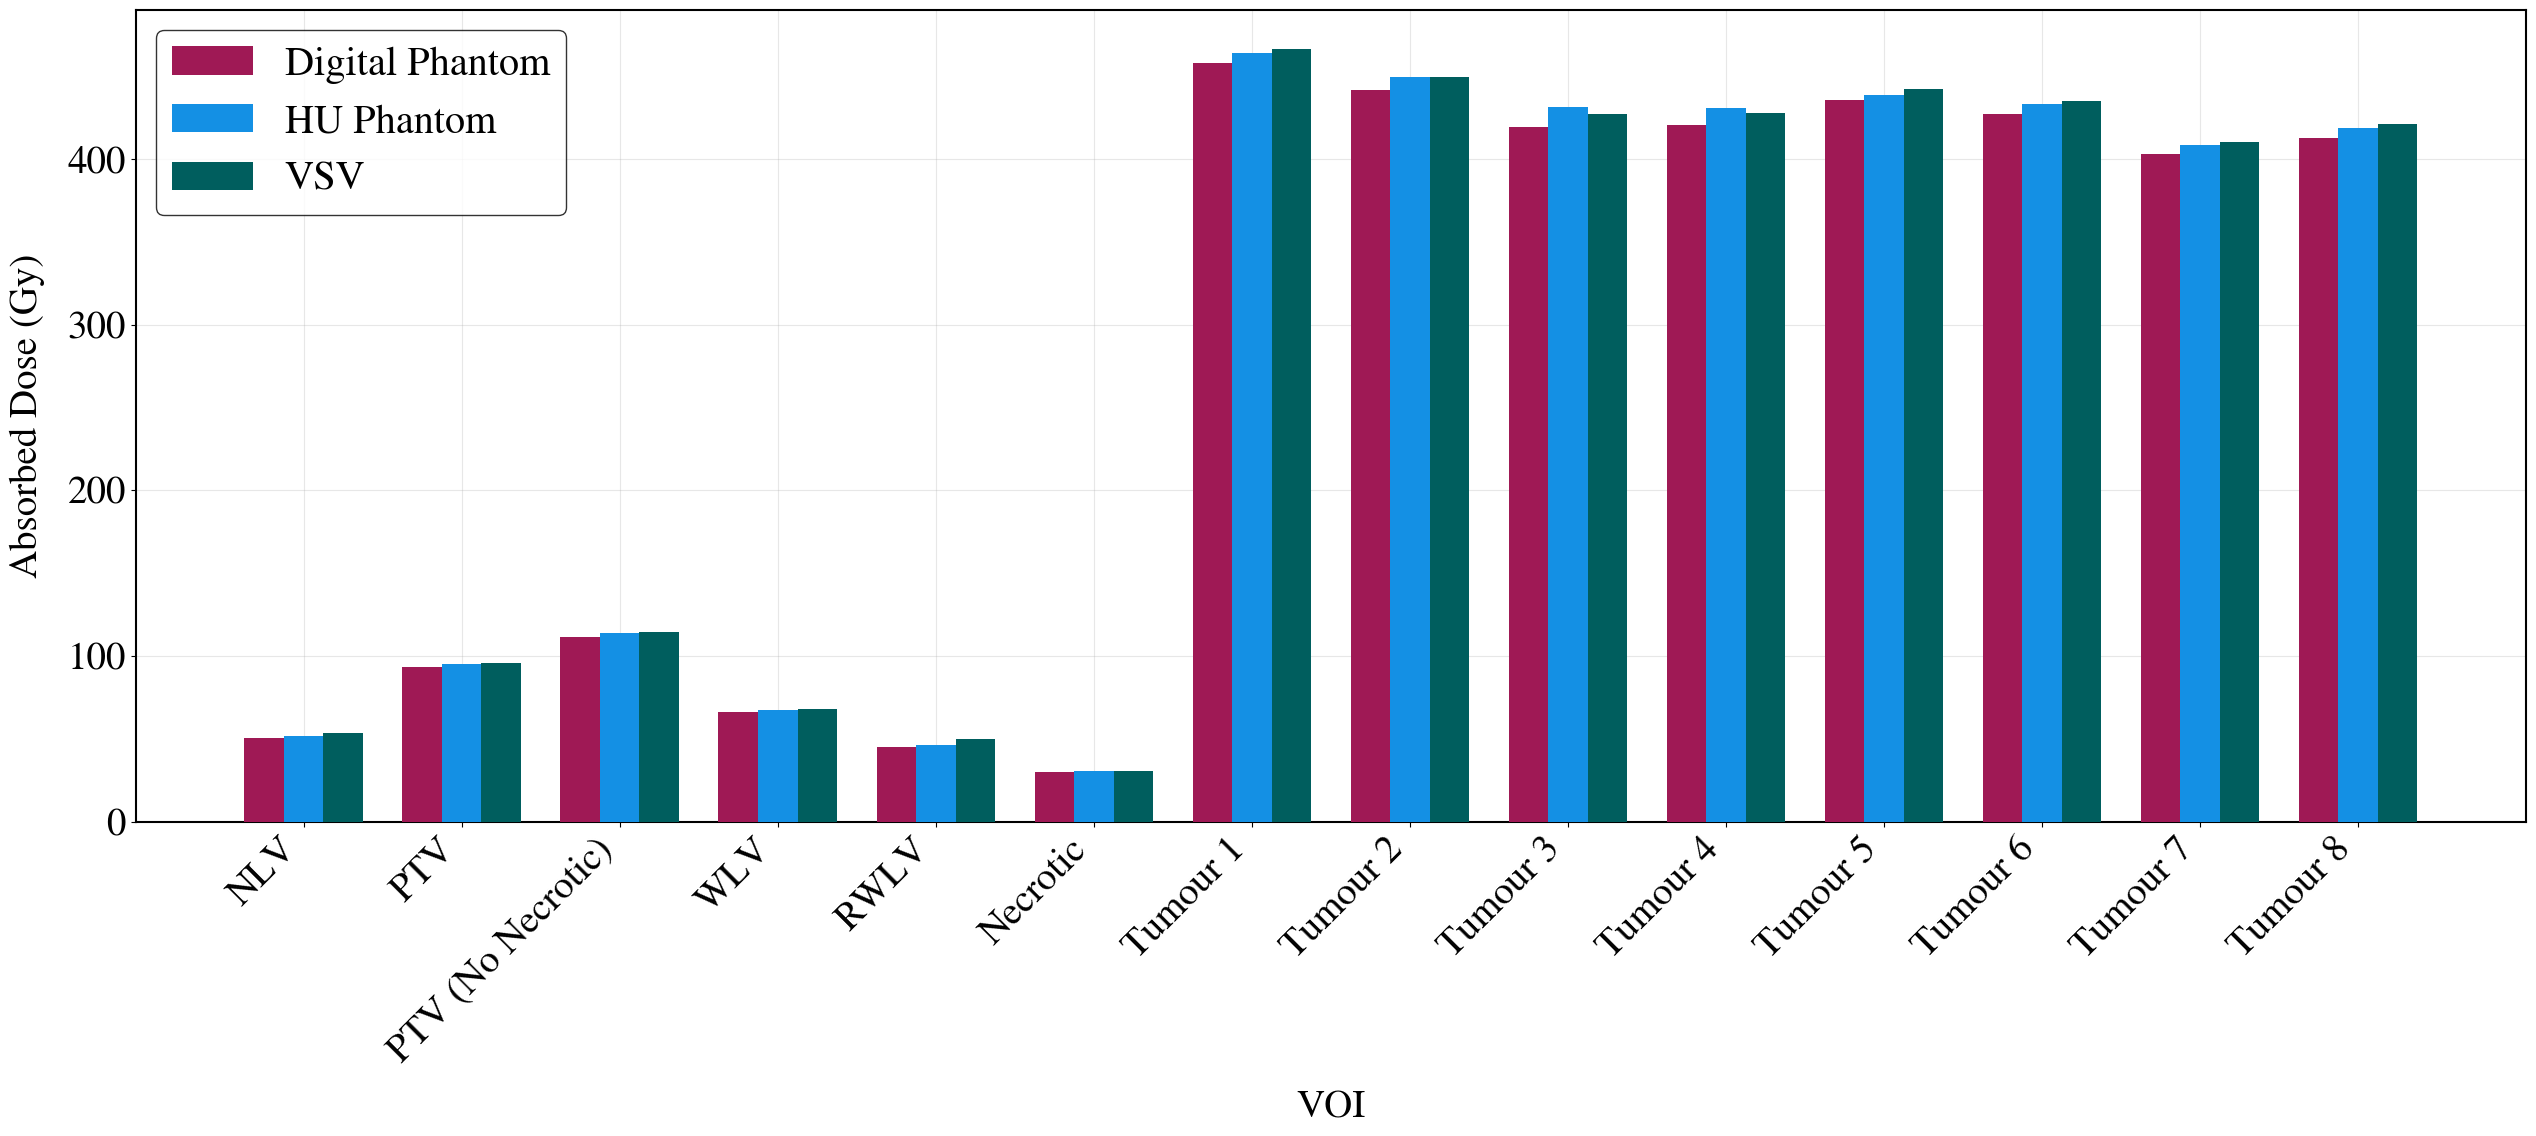

In [126]:
# ==========================================================
# MAIN
# ==========================================================
if __name__ == "__main__":

    vsv_dose_path = "/home/administrator/Champalimaud dados/Imagens/ab_dose_y90.nii"
    mc_dose_path_hu = "/home/administrator/Secretária/Results_MC_Dosimetry/OUTPUT_Dosimetry_Simulation_CTPhantom_1.18e8/Patient_ADD_MCdosimetry_ctphantom118e8.nii.gz"
    mc_dose_path_3dslicer = "/home/administrator/Secretária/Results_MC_Dosimetry/OUTPUT_Dosimetry_Simulation_3DSlicerPhantom_1.18e8/Patient_ADD_MCdosimetry_3dslicer.nii.gz"
    voi_folder = "/home/administrator/Secretária/Results_MC_Dosimetry/VOIs"

    # Compute stats and KEEP the returned dataframes
    df_vsv = statistics_multiple_vois(load_nii(vsv_dose_path), voi_folder, "VSV_stats.txt")
    df_hu = statistics_multiple_vois(load_nii(mc_dose_path_hu), voi_folder, "HU_stats.txt")
    df_digital = statistics_multiple_vois(load_nii(mc_dose_path_3dslicer), voi_folder, "Digital_stats.txt")

    # Plot
    fig, ax = dose_barplot_latex(df_hu, df_digital, df_vsv)
    plt.show()

## HU Phantom DVHs and Statistics

=== VSV Statistics ===

Statistics saved to VSV_stats.txt



,VOI,Voxels,Mean Absorbed Dose,Std,Min,Max
0,RWLV.nii,291448,49.8305,84.4567,0.0000,609.7505
1,Tumour1.nii,350,466.4029,55.7297,389.7897,609.7505
2,Tumour2.nii,932,449.3900,45.7719,389.5192,600.4971
3,Tumour3.nii,221,426.8202,22.3099,390.5407,487.1923
4,Tumour4.nii,469,427.7602,27.8734,389.6504,524.2223
5,Tumour5.nii,132,441.9292,39.5270,389.5275,539.3661
6,Tumour6.nii,42,434.6300,30.3914,392.3877,505.4650
7,Tumour7.nii,19,410.3127,12.5883,390.4970,435.6397
8,Tumour8.nii,107,420.7517,19.9718,389.6786,468.3548
9,WLV.nii,195696,68.1760,96.8555,0.0000,609.7505



=== MC Statistics ===

Statistics saved to MC_stats.txt



,VOI,Voxels,Mean Absorbed Dose,Std,Min,Max
0,RWLV.nii,291448,46.4914,84.9618,0.0000,601.2131
1,Tumour1.nii,350,463.6063,55.4310,379.4646,601.2131
2,Tumour2.nii,932,449.5394,45.6438,378.1844,601.1882
3,Tumour3.nii,221,431.3754,23.1960,388.4882,488.4215
4,Tumour4.nii,469,430.6385,28.0743,384.1275,526.3801
5,Tumour5.nii,132,438.4582,39.4375,379.8186,537.3268
6,Tumour6.nii,42,433.2643,31.3864,387.6643,514.0717
7,Tumour7.nii,19,408.3818,12.6038,385.3430,430.9962
8,Tumour8.nii,107,418.4901,19.9800,387.0642,469.6306
9,WLV.nii,195696,67.5312,96.7735,0.0000,601.2131


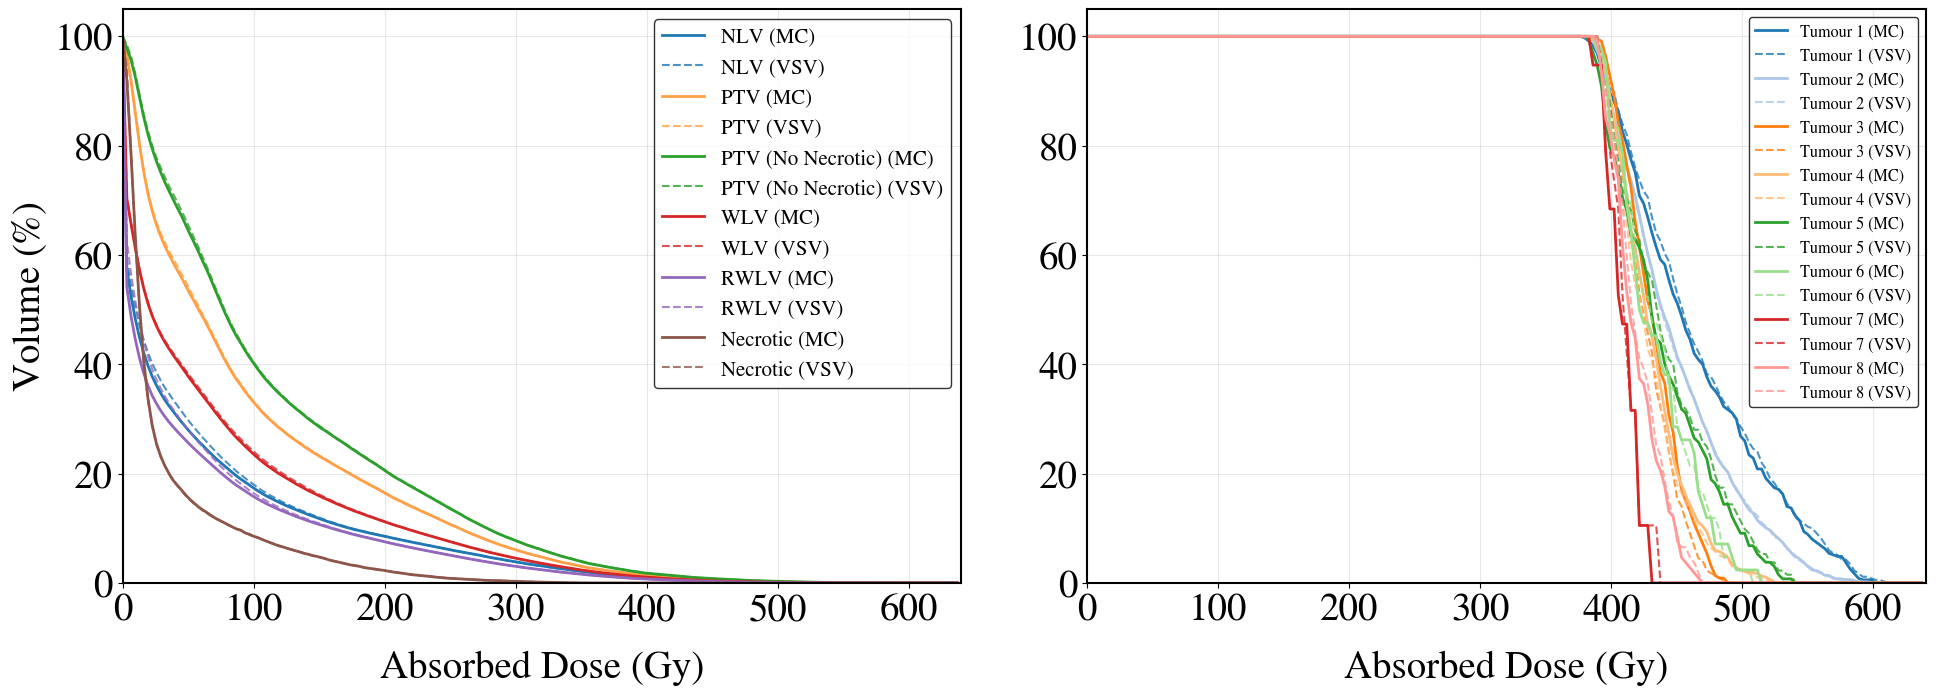

In [ ]:
# ==========================================================
# MAIN EXECUTION
# ==========================================================
if __name__ == "__main__":

    setup_latex()

    vsv_dose_path="/home/administrator/Champalimaud dados/Imagens/ab_dose_y90.nii"
    mc_dose_path="/home/administrator/Secretária/Results_MC_Dosimetry/OUTPUT_Dosimetry_Simulation_CTPhantom_1.18e8/Patient_ADD_MCdosimetry_ctphantom118e8.nii.gz"
    voi_folder="/home/administrator/Secretária/Results_MC_Dosimetry/VOIs"

    print("=== VSV Statistics ===")
    statistics_multiple_vois(load_nii(vsv_dose_path),voi_folder,"VSV_stats.txt")

    print("\n=== MC Statistics ===")
    statistics_multiple_vois(load_nii(mc_dose_path),voi_folder,"MC_stats.txt")

    # ======================================================
    # SIDE-BY-SIDE DVH WITH SHARED TITLE
    # ======================================================
    fig,axes=plt.subplots(1,2,figsize=(20,8))

    combined_dvh_main_vois(axes[0],vsv_dose_path,mc_dose_path,voi_folder)
    combined_dvh_tumors(axes[1],vsv_dose_path,mc_dose_path,voi_folder)

    # ===== SHARED GLOBAL TITLE =====
    #fig.suptitle("HU Phantom", fontsize=24, y=0.91)

    plt.tight_layout(rect=[0,0,1,0.95])
    plt.savefig("combined_dvh_panels.pdf",dpi=300,bbox_inches="tight")
    fig.subplots_adjust(wspace=0.15)
    plt.savefig(
    "/home/administrator/Secretária/Results_MC_Dosimetry/huphantomdvh.png",
    dpi=600,              # VERY high quality
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)
    plt.show()

## Digital Phantom DVHs and Statistics

=== VSV Statistics ===

Statistics saved to VSV_stats.txt



,VOI,Voxels,Mean Absorbed Dose,Std,Min,Max
0,RWLV.nii,291448,49.8305,84.4567,0.0000,609.7505
1,Tumour1.nii,350,466.4029,55.7297,389.7897,609.7505
2,Tumour2.nii,932,449.3900,45.7719,389.5192,600.4971
3,Tumour3.nii,221,426.8202,22.3099,390.5407,487.1923
4,Tumour4.nii,469,427.7602,27.8734,389.6504,524.2223
5,Tumour5.nii,132,441.9292,39.5270,389.5275,539.3661
6,Tumour6.nii,42,434.6300,30.3914,392.3877,505.4650
7,Tumour7.nii,19,410.3127,12.5883,390.4970,435.6397
8,Tumour8.nii,107,420.7517,19.9718,389.6786,468.3548
9,WLV.nii,195696,68.1760,96.8555,0.0000,609.7505



=== MC Statistics ===

Statistics saved to MC_stats.txt



,VOI,Voxels,Mean Absorbed Dose,Std,Min,Max
0,RWLV.nii,291448,45.4882,83.3578,0.0000,596.2797
1,Tumour1.nii,350,457.9934,54.9148,376.7041,593.4213
2,Tumour2.nii,932,441.4500,45.1746,375.2870,596.2797
3,Tumour3.nii,221,419.2528,22.6279,377.8767,481.4636
4,Tumour4.nii,469,420.2256,28.4783,375.0379,521.1575
5,Tumour5.nii,132,435.6668,39.2803,376.9768,538.2068
6,Tumour6.nii,42,427.2266,30.5931,383.2325,506.4931
7,Tumour7.nii,19,402.6862,12.1533,376.2484,423.6971
8,Tumour8.nii,107,412.2461,19.8666,380.1184,462.2051
9,WLV.nii,195696,66.2408,94.8972,0.0000,596.2797


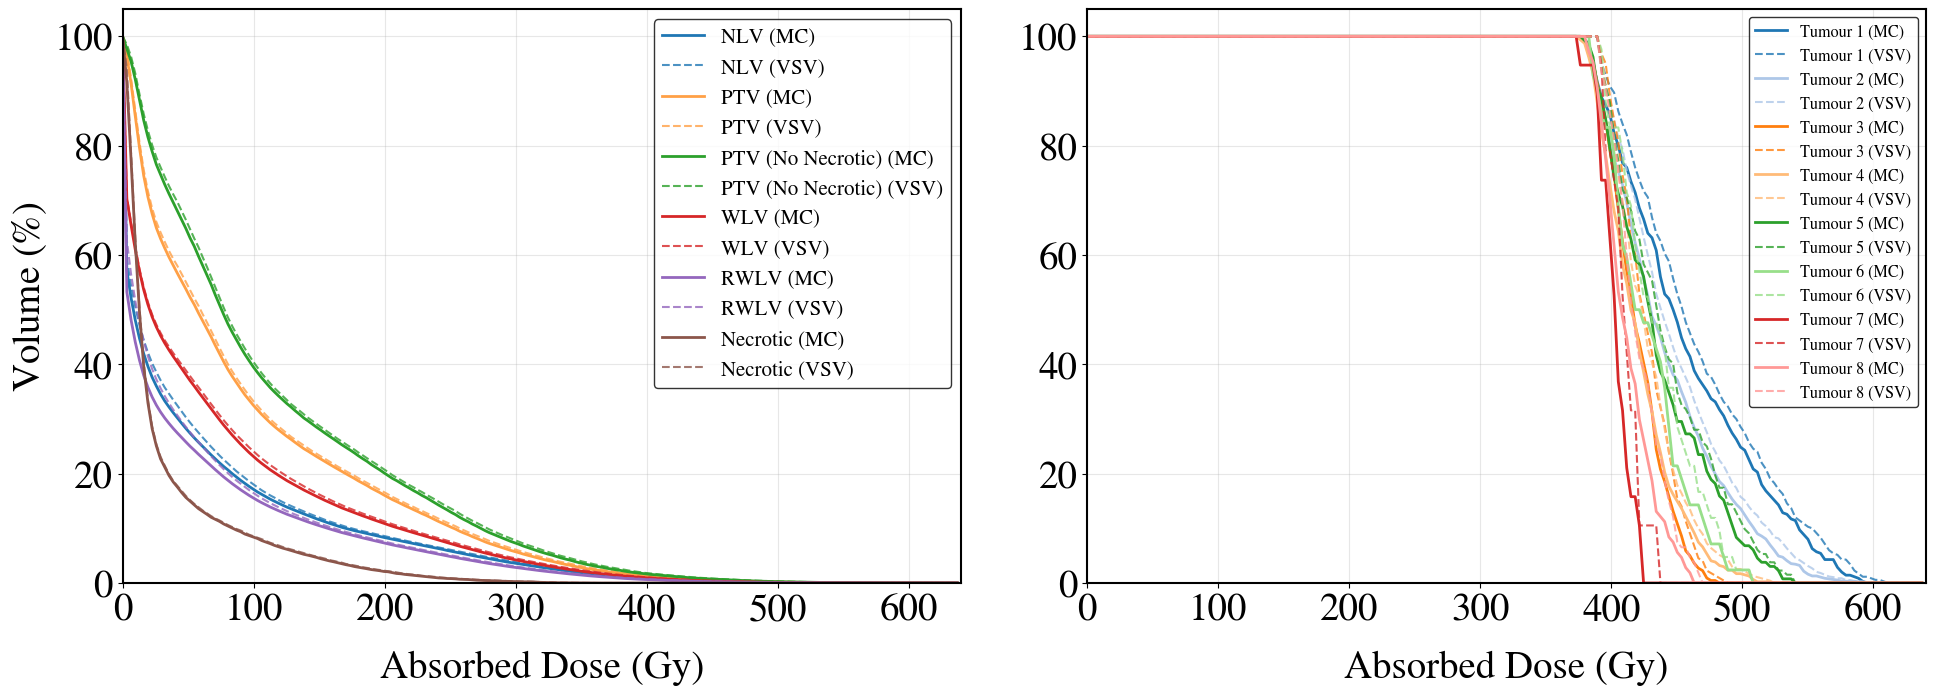

In [35]:
# ==========================================================
# MAIN EXECUTION
# ==========================================================
if __name__ == "__main__":

    setup_latex()

    vsv_dose_path="/home/administrator/Champalimaud dados/Imagens/ab_dose_y90.nii"
    mc_dose_path="/home/administrator/Secretária/Results_MC_Dosimetry/OUTPUT_Dosimetry_Simulation_3DSlicerPhantom_1.18e8/Patient_ADD_MCdosimetry_3dslicer.nii.gz"
    voi_folder="/home/administrator/Secretária/Results_MC_Dosimetry/VOIs"

    print("=== VSV Statistics ===")
    statistics_multiple_vois(load_nii(vsv_dose_path),voi_folder,"VSV_stats.txt")

    print("\n=== MC Statistics ===")
    statistics_multiple_vois(load_nii(mc_dose_path),voi_folder,"MC_stats.txt")

    # ======================================================
    # SIDE-BY-SIDE DVH WITH SHARED TITLE
    # ======================================================
    fig,axes=plt.subplots(1,2,figsize=(20,8))

    combined_dvh_main_vois(axes[0],vsv_dose_path,mc_dose_path,voi_folder)
    combined_dvh_tumors(axes[1],vsv_dose_path,mc_dose_path,voi_folder)

    # ===== SHARED GLOBAL TITLE =====

    plt.tight_layout(rect=[0,0,1,0.95])
    plt.savefig("combined_dvh_panels.pdf",dpi=300,bbox_inches="tight")
    fig.subplots_adjust(wspace=0.15)
    plt.savefig(
    "/home/administrator/Secretária/Results_MC_Dosimetry/digitalphantomdvh.png",
    dpi=600,              # VERY high quality
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)
    plt.show()